### Adaptive RAG

Adaptive RAG (Retrieval-Augmented Generation) is a framework that dynamically adjusts its strategy for handling queries based on their complexity. It's like a smart assistant that knows when to dig deep for information and when to provide a simple answer. Instead of using a single, rigid approach, Adaptive RAG chooses the most appropriate retrieval method for each query, balancing speed and accuracy.

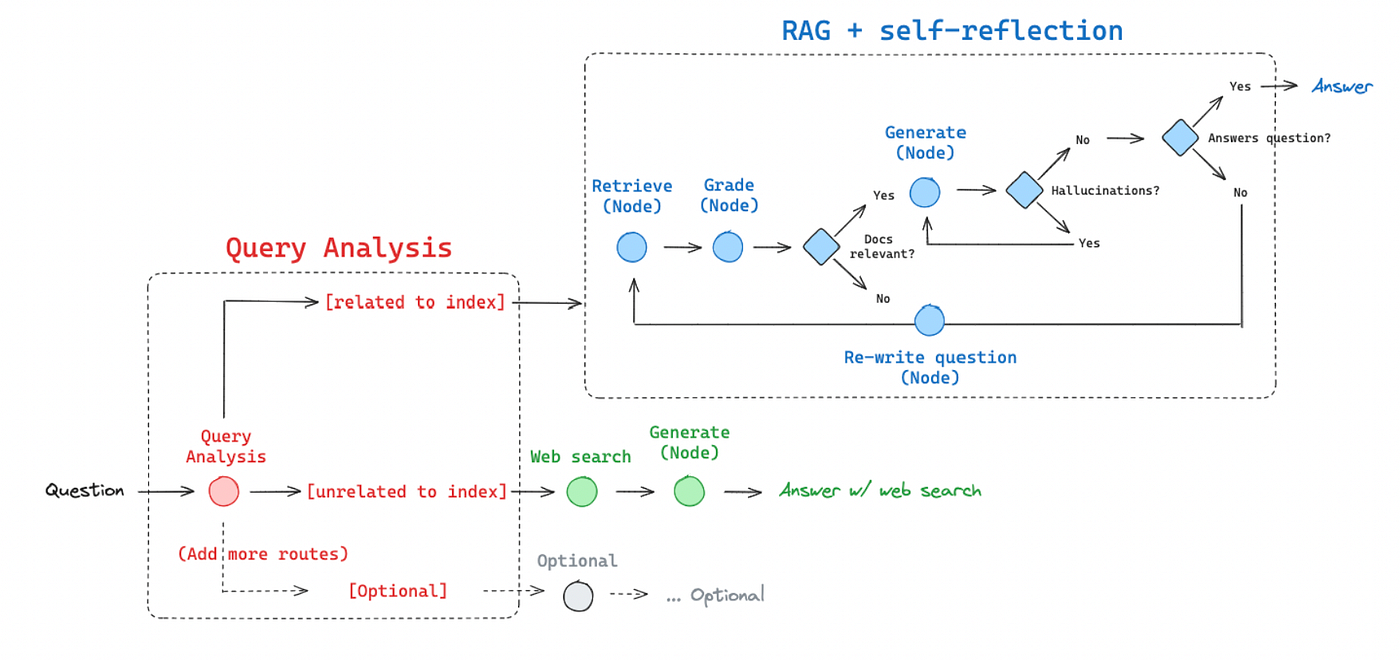

In [43]:
# ------------------------------------------------------------
# 1. Web Document, Vector DB, LLM and Embeddings 
# ------------------------------------------------------------

from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_ollama.embeddings import OllamaEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')
os.environ['TAVILY_API_KEY'] = os.getenv('tavily_api_key')

# Url
urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/'
]

# Web Loader
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Splitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
doc_split = text_splitter.split_documents(docs_list)

embedding = OllamaEmbeddings(model='nomic-embed-text')

# Vector Store
vector_db = FAISS.from_documents(doc_split, embedding)
vector_retriever = vector_db.as_retriever()

In [44]:
# ------------------------------------------------------------
# 2. Router - Retriever from Vector DB or Web Search
# ------------------------------------------------------------

from pydantic import BaseModel, Field
from typing import Literal
from langchain_groq import ChatGroq
from langchain_classic.prompts import ChatPromptTemplate

# Data Model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""
    datasource: Literal['vectorstore', 'web_search'] = Field(..., description='Given a user question choose to route it to web search or a vectorstore.')


# LLM with function call
llm = ChatGroq(model='openai/gpt-oss-120b', max_tokens=1000, temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# Prompt
system_router_prompt = """You are an expert at routing a user question to a vectorstore or web search.
    The vectorstore contains documents related to agents, prompt engineering and adversarial attacks.
    Use the vectorstore for questions on these topics. Otherwise, use web-search."""
    
route_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_router_prompt),
        ('human', '{question}')
    ]
)

# Chain
question_route = route_prompt | structured_llm_router

# Test
print(question_route.invoke({'question': 'who won the world cup in 2025?'}))
print(question_route.invoke({'question': 'What are the types of agent memory?'}))

datasource='web_search'
datasource='vectorstore'


In [45]:
# ------------------------------------------------------------
# 3. Retrieval Grader - Check the document based on the user question. Return 'Yes' or 'No'
# ------------------------------------------------------------

class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    
    binary_score: str = Field(description='Documents are relevant to the question, "yes" or "No"')
    
# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system_grade_prompt = """You are a grader assessing relevance of a retrieved document to a user question. \n
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_grade_prompt),
        ('human', 'Retrieved document:\n\n{document}\n\nUser Question: {question}')
    ]
)

# Chain
retrieval_grader = grade_prompt | structured_llm_grader

# Test
question = 'agent memory'

# Context
docs = vector_retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({'question': question, 'document': doc_txt}))

binary_score='yes'


In [46]:
# ------------------------------------------------------------
# 4. Generate - Generate the answer based on the retrieval grader
# ------------------------------------------------------------

from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = hub.pull('rlm/rag-prompt')

# Post-Preprocessing
def format_docs(docs):
    return '\n\n'.join(doc.page_content for doc in docs)

# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({'context': docs, 'question': question})

print(generation)

Agent memory consists of two parts: short‑term memory, which is the in‑context learning the LLM uses during a single interaction, and long‑term memory, which stores information persistently—often in an external vector store that can be retrieved quickly. Long‑term memory lets the agent retain and recall essentially unlimited knowledge across sessions. This combination enables the agent to act based on both immediate context and past experience.


In [47]:
# ------------------------------------------------------------
# 5. Hallucination Grader
# ------------------------------------------------------------

from pydantic import BaseModel, Field

class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""
    
    binary_score: str = Field(description='Answer is grounded in the facts, "yes" or "no"')
    
# LLM with function call
structured_llm_hallu = llm.with_structured_output(GradeHallucinations)

# Prompt
system_hallu_prompt = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n
    Give a binary score 'yes' or 'no'. 'yes' means that the answer is grounded in / supported by the set of facts."""
    
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_hallu_prompt),
        ('human', 'Set of facts: \n\n {documents} \n\n LLM generation: {generation}')
    ]
)

# Chain
hallucination_grade = hallucination_prompt | structured_llm_hallu

# Test
print(hallucination_grade.invoke({'documents': docs, 'generation': generation}))

binary_score='yes'


In [48]:
# ------------------------------------------------------------
# 6. Answer Grader
# ------------------------------------------------------------

class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""
    
    binary_score: str = Field(description='Answer addresses the question, "yes" or "no"')
    
# LLM with function call
structured_llm_answer = llm.with_structured_output(GradeAnswer)

# Prompt
system_answer_prompt = """You are a grader assessing whether an answer addresses / resolves a question \n
    Give a binary score 'yes' or 'no'. 'yes' means that the answer resolves the question."""
    
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_answer_prompt),
        ('human', 'User question: \n\n {question} \n\n LLM Generate: {generation}')
    ]
)

# Chain
answer_grade = answer_prompt | structured_llm_answer

# Test
print(answer_grade.invoke({'question': question, 'generation': generation}))

binary_score='yes'


In [49]:
# ------------------------------------------------------------
# 7. Question Re-Write
# ------------------------------------------------------------

# Prompt
system_rewrite_prompt = """You a question re-writer that converts an input question to a better version that is optimized \n
    for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
    
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_rewrite_prompt),
        ('human', 'Here is the initial question: \n\n {question} \n Formulate an improved question.')
    ]
)

# Chain
question_rewrite = rewrite_prompt | llm | StrOutputParser()

# Test
print(question_rewrite.invoke({'question': question}))

**Improved question:**  
*What are the common techniques and architectures used for implementing memory in autonomous AI agents, and how do these methods enable the agents to store, retrieve, and update contextual information over time?*


In [50]:
# ------------------------------------------------------------
# 8. Web Search - Tavily
# ------------------------------------------------------------

from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(k=3)

In [51]:
# ------------------------------------------------------------
# 9. Graph State
# ------------------------------------------------------------

from typing import TypedDict, List
from langchain_classic.schema import Document

class GraphState(TypedDict):
    """
    Represents the state of our graph
    
    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """
    
    question: str
    generation: str
    documents: List[Document]

In [57]:
# ------------------------------------------------------------
# 10. 
# ------------------------------------------------------------

def retrieve(state: GraphState) -> GraphState:
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print('---------------- RETRIEVE ----------------')
    question = state['question']
    
    # Retrieval
    documents = vector_retriever.invoke(question)
    
    return {'documents': documents, 'question': question}

def generate(state: GraphState) -> GraphState:
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contain LLM generation
    """
    print('---------------- GENERATE ----------------')
    question = state['question']
    documents = state['documents']
    
    # RAG Generation
    generation = rag_chain.invoke({'context': format_docs(documents), 'question': question})
    
    return {'documents': documents, 'question': question, 'generation': generation}

def grade_documents(state: GraphState) -> GraphState:
    """
    Determines whether the retrieved documents are relevant to the question

    Args:
        state (dict): The current graph state 

    Returns:
        state (dict): Updates documents key with only filtered relevant documents 
    """
    print('---------------- CHECK DOCUMENT RELEVANCE TO QUESTION ----------------')
    question = state['question']
    documents = state['documents']
    
    # Score each doc
    filter_docs = []
    for d in documents:
        score = retrieval_grader.invoke({'question': question, 'document': d.page_content})
        grade = score.binary_score
        if grade == 'yes':
            print('---------------- GRADE: DOCUMENT RELEVANT ----------------')
            filter_docs.append(d)
        else:
            print('---------------- GRADE: DOCUMENT NOT RELEVANT ----------------')
            continue
    return {'documents': filter_docs, 'question': question}

def transform_query(state: GraphState) -> GraphState:
    """
    Transform the query to produce a better question.
    
    Args:
        state (dict): The current graph state
        
    Return:
        state (dict): Updates question key with a re-phrased question
    """
    print('---------------- TRANSFORM QUERY ----------------')
    question = state['question']
    documents = state['documents']
    
    # Re-Write question
    better_question = question_rewrite.invoke({'question': question})
    
    return {'documents': documents, 'question': better_question}

def web_search(state: GraphState) -> GraphState:
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """
    print('---------------- WEB SEARCH ----------------')
    question = state['question']
    
    # Web Search
    response = web_search_tool.invoke({'query': question})
    
    # Handle Tavily response safely
    if isinstance(response, dict) and "results" in response:
        docs = response["results"]
        web_results = "\n".join([d["content"] for d in docs if "content" in d])
    else:
        # fallback (string or unexpected format)
        web_results = str(response)
        
    web_results = Document(page_content=web_results)
    
    return {'documents': [web_results], 'question': question}

# Edges
def route_question(state: GraphState) -> GraphState:
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Next node to call
    """
    print('---------------- ROUTE QUESTION ----------------')
    question = state['question']
    source = question_route.invoke({'question': question})
    
    if source.datasource == 'web_search':
        print('---------------- ROUTE QUESTION TO WEB SEARCH ----------------')
        return 'web_search'
    elif source.datasource == 'vectorstore':
        print('---------------- ROUTE QUESTION TO RAG ----------------')
        return 'vectorstore'
    
def decide_to_generate(state: GraphState) -> GraphState:
    """
    Determines whether to generate an answer or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """
    print('---------------- ASSESS GRADED DOCUMENTS ----------------')
    state['question']
    filtered_documents = state['documents']
    
    if not filtered_documents:
        # All documents have been filtered check_relevance
        # Will re-generate a new query
        print('---------------- DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY ----------------')
        return 'transform_query'
    else:
        # Relevant documents, so generate answer
        print('---------------- DECISION: GENERATE ----------------')
        return 'generate'
    
def grade_generation_v_documents_and_question(state: GraphState) -> GraphState:
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """
    print('---------------- CHECK HALLUCINATIONS ----------------')
    question = state['question']
    documents = state['documents']
    generation = state['generation']
    
    score = hallucination_grade.invoke({'documents': documents, 'generation': generation})
    grade = score.binary_score
    
    # Check hallucination
    if grade == 'yes':
        print('---------------- DECISION: GENERATION IS GROUNDED IN DOCUMENTS ----------------')
        # Check question-answering
        print('---------------- GRADE GENERATION vs QUESTION ----------------')
        score = answer_grade.invoke({'question': question, 'generation': generation})
        grade = score.binary_score
        if grade == 'yes':
            print('---------------- DECISION: GENERATION ADDRESS QUESTION ----------------')
            return 'useful'
        else:
            print('---------------- DECISION: GENERATION DOES NOT ADDRESS QUESTION ----------------')
            return 'not useful'
    else:
        print('---------------- DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY ----------------')
        return 'not supported'

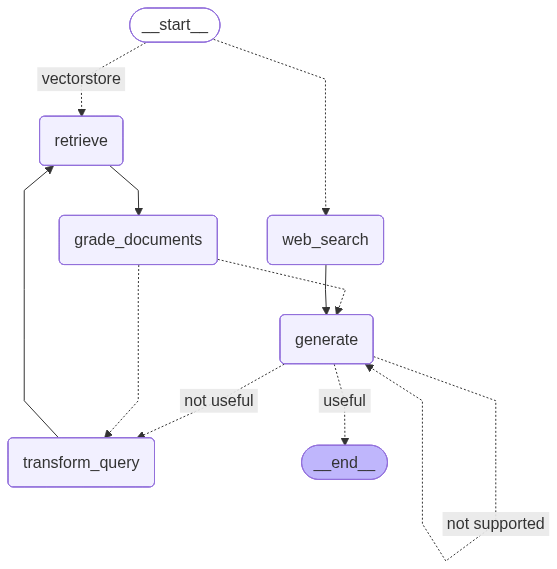

In [58]:
# ------------------------------------------------------------
# 11. State Graph
# ------------------------------------------------------------

from langgraph.graph import StateGraph, START, END

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node('web_search', web_search) # web search
workflow.add_node('retrieve', retrieve) # retrieve
workflow.add_node('grade_documents', grade_documents) # grade documents
workflow.add_node('generate', generate) # generate
workflow.add_node('transform_query', transform_query) # transform query

# Build Graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'web_search': 'web_search',
        'vectorstore': 'retrieve'
    }
)

workflow.add_edge('web_search', 'generate')
workflow.add_edge('retrieve', 'grade_documents')
workflow.add_conditional_edges(
    'grade_documents',
    decide_to_generate,
    {
        'transform_query': 'transform_query',
        'generate': 'generate'
    }
)
workflow.add_edge('transform_query', 'retrieve')
workflow.add_conditional_edges(
    'generate',
    grade_generation_v_documents_and_question,
    {
        'not supported': 'generate',
        'useful': END,
        'not useful': 'transform_query'
    }
)

# Compile
app = workflow.compile()
app

In [59]:
result = app.invoke({'question': 'what is machine learning?'})

print(result)

---------------- ROUTE QUESTION ----------------
---------------- ROUTE QUESTION TO WEB SEARCH ----------------
---------------- WEB SEARCH ----------------
---------------- GENERATE ----------------
---------------- CHECK HALLUCINATIONS ----------------
---------------- DECISION: GENERATION IS GROUNDED IN DOCUMENTS ----------------
---------------- GRADE GENERATION vs QUESTION ----------------
---------------- DECISION: GENERATION ADDRESS QUESTION ----------------
{'question': 'what is machine learning?', 'generation': 'Machine learning is a subfield of artificial intelligence that uses algorithms trained on data to create models capable of making predictions, classifications, or other decisions without explicit programming. By learning patterns from training data, these models can perform tasks such as image recognition, price forecasting, or language generation. In essence, it is the process of teaching software to improve its performance automatically through experience with data.'